# Data Statistics

In this notebook, i try to show some statistic about finance data

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
%matplotlib inline

In [38]:
# lets read all csv files to get one big chunk
df_main = pd.DataFrame()
for file in os.listdir("../input/raw_data"):
    df = pd.read_csv("../input/raw_data/"+file)
    
    # insert percent change column into main dataframe
    percentage = df.adjusted_close.pct_change(periods=1)
    percentage.iloc[0] = 0.0
    df['percent_change'] = percentage
    
    # calculate change of values between days
    shifted = df.adjusted_close.shift(periods=1)
    shifted[0] = 0.0
    diff = df.adjusted_close - shifted
    diff[0] = 0.0
    df['change'] = diff  
    
    
    
    df_main = pd.concat([df_main,df]) 
df_main = df_main.reset_index(drop=True)

In [39]:
df = pd.read_csv("../input/raw_data/spy.csv")
# insert percent change column into main dataframe
percentage = df.adjusted_close.pct_change(periods=1)
percentage.iloc[0] = 0.0
df['percent_change'] = percentage

# calculate change of values between days
shifted = df.adjusted_close.shift(periods=1)
shifted[0] = 0.0
diff = df.adjusted_close - shifted
diff[0] = 0.0
df['change'] = diff
df.head()

,date,open,high,low,close,volume,adjusted_close,percent_change,change
0,2000-01-03,148.25,148.25,143.88,145.44,8164300.0,145.44,0.000000,0.00
1,2000-01-04,143.53,144.06,139.64,139.75,8085300.0,139.75,-0.039123,-5.69
2,2000-01-05,139.94,141.53,137.25,140.00,12177900.0,140.00,0.001789,0.25
3,2000-01-06,139.62,141.50,138.88,139.56,6142800.0,139.56,-0.003143,-0.44
4,2000-01-07,140.31,145.75,140.06,145.75,8066600.0,145.75,0.044354,6.19


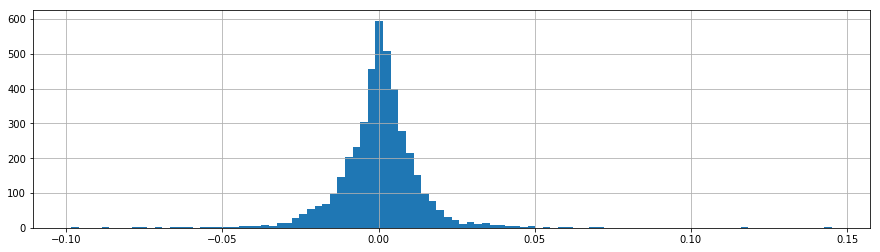

In [40]:
df.percent_change.hist(bins=100, figsize=(15,4)) # as expected it is a normal distribution

In [41]:
# i wanna create some helper function
import math
def sigmoid(x):
    return 1/(1+math.exp(-x))

def split_count(series, threshold):
    return (series.loc[series < -threshold].count(),
                series.loc[np.logical_and(series <= threshold,series >= -threshold)].count(),
                series.loc[series > threshold].count())

def split(series, threshold):
    return (series.loc[series < -threshold],
                series.loc[np.logical_and(series <= threshold,series >= -threshold)],
                series.loc[series > threshold])

def normalize_1_1(series):
    norm_0_1 = (series - series.min()) / (series.max()- series.min()) #normalized btw 0 to 1
    return norm_0_1*2 - 1  #normalized btw -1 to 1

def normalize_mean_var(series):
    return (series - series.mean()) / series.std()

In [42]:
# below shows the distribution of the percent change
split_count(df.percent_change, 0.0)

(1979, 30, 2277)

In [43]:
# when we have too little values like 0.003 , 0.004, tanh function does not expand data so well.
# so i want to make values bigger. so lets drop percent and multiply with 100.
df['percent_change_mul_100'] = df.percent_change * 100
# now i can apply tanh function to spread values between -1 to 1.
df['percent_change_mul_100_tanh'] = df.percent_change_mul_100.apply(np.tanh)

In [44]:
df.head()

,date,open,high,low,close,volume,adjusted_close,percent_change,change,percent_change_mul_100,percent_change_mul_100_tanh
0,2000-01-03,148.25,148.25,143.88,145.44,8164300.0,145.44,0.000000,0.00,0.000000,0.000000
1,2000-01-04,143.53,144.06,139.64,139.75,8085300.0,139.75,-0.039123,-5.69,-3.912266,-0.999201
2,2000-01-05,139.94,141.53,137.25,140.00,12177900.0,140.00,0.001789,0.25,0.178891,0.177007
3,2000-01-06,139.62,141.50,138.88,139.56,6142800.0,139.56,-0.003143,-0.44,-0.314286,-0.304331
4,2000-01-07,140.31,145.75,140.06,145.75,8066600.0,145.75,0.044354,6.19,4.435368,0.999719


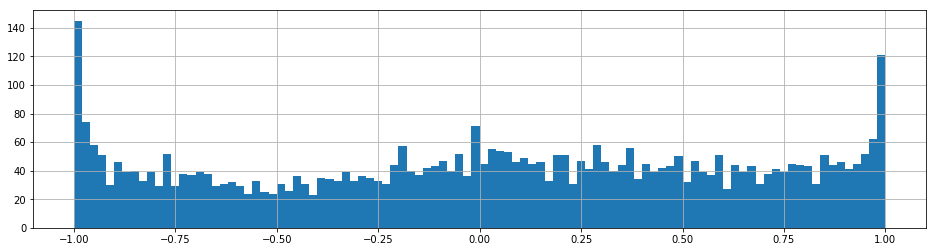

In [45]:
df.percent_change_mul_100_tanh.hist(bins=100, figsize=(16,4))

In [46]:
split_count(df.percent_change_mul_100_tanh, 0.38)

(1226, 1674, 1386)

In [47]:
# with the help of split function, i split values in 3 different case.
below,same,above = split(df.percent_change_mul_100_tanh, 0.38)

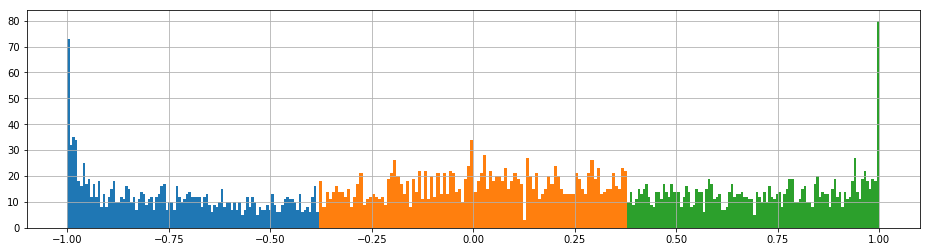

In [48]:
# when i plot their histogram. i can see what i want.

below.hist(bins=100, figsize=(16,4))
same.hist(bins=100, figsize=(16,4))
above.hist(bins=100, figsize=(16,4))

# Variance minimization

**Note**
Up to now, i normalized the data and get rougly 3 label from it.
From precision point of view, i want to create a function which split whole data into 3 chunks while minimizing sum of variances.

In [49]:
var_list = []
for i in range(100):
    ratio = i/100
    below,same,above = split(df.percent_change_mul_100_tanh, ratio) 
    var_list.append(below.var() + same.var() + above.var())
np.argmin(var_list)/100 # argmin of variance list

0.40000000000000002

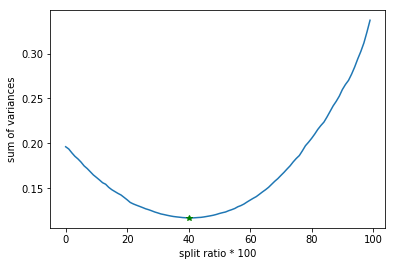

In [50]:
plt.plot(var_list)
plt.plot(np.argmin(var_list),np.min(var_list),'g*')
plt.ylabel("sum of variances")
plt.xlabel("split ratio * 100")

As seen above, i will chose split ratio as **0.38** and use the normalized data as **"np.tanh(percent_change*100)"**

In [51]:
df.percent_change_mul_100_tanh.describe()

count    4286.000000
mean        0.024952
std         0.604452
min        -1.000000
25%        -0.483606
50%         0.052179
75%         0.529657
max         1.000000
Name: percent_change_mul_100_tanh, dtype: float64

In [52]:
df.change.describe()

count    4286.00000
mean        0.01822
std         1.52688
min        -9.83000
25%        -0.72000
50%         0.07000
75%         0.82000
max        12.85000
Name: change, dtype: float64

In [53]:
below,same,above = split(df.percent_change_mul_100_tanh, 0.38) 

In [54]:
below.describe()

count    1226.000000
mean       -0.748204
std         0.189887
min        -1.000000
25%        -0.928499
50%        -0.768452
75%        -0.594227
max        -0.380068
Name: percent_change_mul_100_tanh, dtype: float64

In [55]:
same.describe()

count    1674.000000
mean        0.018564
std         0.212200
min        -0.379001
25%        -0.154658
50%         0.023511
75%         0.198503
max         0.379982
Name: percent_change_mul_100_tanh, dtype: float64

In [56]:

max_c = df.adjusted_close.max()
min_c = df.adjusted_close.min()
df['adj_close_01'] = df.adjusted_close.apply(lambda x: (x-min_c)/(max_c - min_c))
df.head()

,date,open,high,low,close,volume,adjusted_close,percent_change,change,percent_change_mul_100,percent_change_mul_100_tanh,adj_close_01
0,2000-01-03,148.25,148.25,143.88,145.44,8164300.0,145.44,0.000000,0.00,0.000000,0.000000,0.484372
1,2000-01-04,143.53,144.06,139.64,139.75,8085300.0,139.75,-0.039123,-5.69,-3.912266,-0.999201,0.448732
2,2000-01-05,139.94,141.53,137.25,140.00,12177900.0,140.00,0.001789,0.25,0.178891,0.177007,0.450298
3,2000-01-06,139.62,141.50,138.88,139.56,6142800.0,139.56,-0.003143,-0.44,-0.314286,-0.304331,0.447541
4,2000-01-07,140.31,145.75,140.06,145.75,8066600.0,145.75,0.044354,6.19,4.435368,0.999719,0.486314


In [57]:
df[['adj_close_01','percent_change_mul_100','percent_change_mul_100_tanh']].describe()

,adj_close_01,percent_change_mul_100,percent_change_mul_100_tanh
count,4286.000000,4286.000000,4286.000000
mean,0.436479,0.017853,0.024952
std,0.225786,1.251612,0.604452
min,0.000000,-9.844767,-1.000000
25%,0.281115,-0.527681,-0.483606
50%,0.385155,0.052226,0.052179
75%,0.519433,0.589669,0.529657
max,1.000000,14.519774,1.000000


In [58]:
df[['adj_close_01','percent_change_mul_100','percent_change_mul_100_tanh']].iloc[:1000].describe()

,adj_close_01,percent_change_mul_100,percent_change_mul_100_tanh
count,1000.000000,1000.000000,1000.000000
mean,0.292828,-0.018766,-0.012447
std,0.128145,1.425278,0.694226
min,0.062574,-6.024263,-0.999988
25%,0.190464,-0.876015,-0.704407
50%,0.279330,0.000000,0.000000
75%,0.411212,0.790838,0.658883
max,0.535233,5.966229,0.999987


In [59]:
df[['adj_close_01','percent_change_mul_100','percent_change_mul_100_tanh']].iloc[-1000:].describe()

,adj_close_01,percent_change_mul_100,percent_change_mul_100_tanh
count,1000.000000,1000.000000,1000.000000
mean,0.786926,0.045236,0.046080
std,0.120809,0.811603,0.525361
min,0.494457,-4.088448,-0.999438
25%,0.711463,-0.343725,-0.330798
50%,0.819919,0.058266,0.058200
75%,0.881381,0.505653,0.466551
max,1.000000,3.979063,0.999301


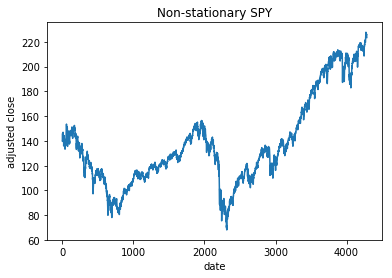

In [75]:
fig = plt.figure()
ax = fig.add_subplot(111)
title = ax.set_title("Non-stationary SPY")
ax.set_xlabel("date")
ax.set_ylabel("adjusted close")


ax.plot(df.adjusted_close)

c:\users\ugur gudelek\appdata\local\programs\python\python35\lib\site-packages\seaborn\timeseries.py:183: UserWarning: The tsplot function is deprecated and will be removed or replaced (in a substantially altered version) in a future release.
  warnings.warn(msg, UserWarning)


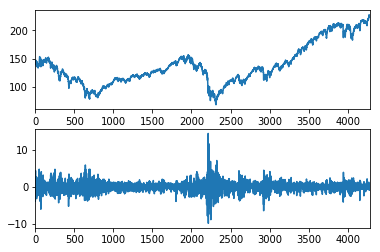

In [76]:
f, (ax1, ax2) = plt.subplots(2)
sns.tsplot(df.adjusted_close, ax=ax1)
sns.tsplot(df.percent_change_mul_100, ax=ax2)

c:\users\ugur gudelek\appdata\local\programs\python\python35\lib\site-packages\ipykernel_launcher.py:2: FutureWarning: pd.rolling_var is deprecated for Series and will be removed in a future version, replace with 
	Series.rolling(window=10,center=True).var()
  
c:\users\ugur gudelek\appdata\local\programs\python\python35\lib\site-packages\ipykernel_launcher.py:3: FutureWarning: pd.rolling_var is deprecated for Series and will be removed in a future version, replace with 
	Series.rolling(window=10,center=True).var()
  This is separate from the ipykernel package so we can avoid doing imports until
c:\users\ugur gudelek\appdata\local\programs\python\python35\lib\site-packages\ipykernel_launcher.py:5: FutureWarning: pd.rolling_mean is deprecated for Series and will be removed in a future version, replace with 
	Series.rolling(window=10,center=True).mean()
  """
c:\users\ugur gudelek\appdata\local\programs\python\python35\lib\site-packages\ipykernel_launcher.py:6: FutureWarning: pd.rolling_

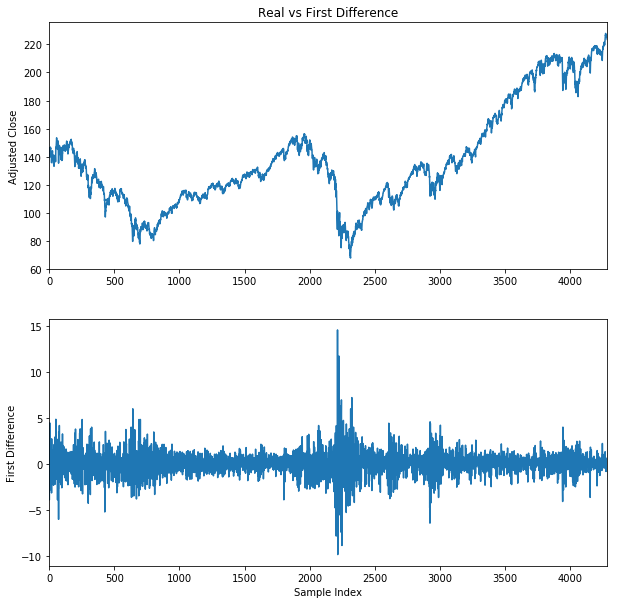

In [97]:
w_size =10
df['Original Variance'] = pd.rolling_var(df.adjusted_close, w_size, min_periods=None, freq=None, center=True)
df['Diff Variance']     = pd.rolling_var(df.percent_change_mul_100, w_size, min_periods=None, freq=None, center=True)

df['Original Mean'] = pd.rolling_mean(df.adjusted_close, w_size, min_periods=None, freq=None, center=True)
df['Diff Mean']     = pd.rolling_mean(df.percent_change_mul_100, w_size, min_periods=None, freq=None, center=True)

fig, ax = plt.subplots(2, 1, figsize=(10,10)) 
ax[0].set_ylabel('Adjusted Close')
ax[1].set_ylabel('First Difference')
ax[1].set_xlabel('Sample Index')
df['adjusted_close'].plot(ax=ax[0], title='Real vs First Difference')
df['percent_change_mul_100'].plot(ax=ax[1])

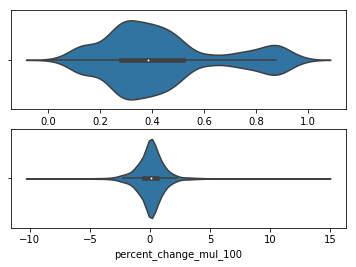

In [73]:
f, (ax1, ax2) = plt.subplots(2)
sns.violinplot(df.adj_close_01, ax=ax1)
sns.violinplot(df.percent_change_mul_100, ax=ax2)

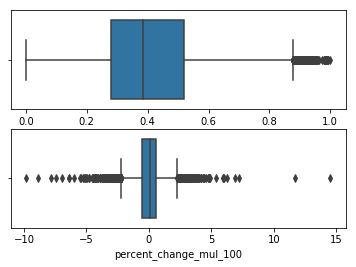

In [74]:
f, (ax1, ax2) = plt.subplots(2)
sns.boxplot(df.adj_close_01, ax=ax1)
sns.boxplot(df.percent_change_mul_100, ax=ax2)